In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import ipaddress
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

In [4]:
home_df   = pd.read_csv("home_flows.csv")
cicids_df = pd.read_csv("Monday-WorkingHours.pcap_ISCX.csv")
unsw_df   = pd.read_csv("UNSWNB15.csv", low_memory=False)


In [5]:
cicids_df.columns = cicids_df.columns.str.strip()

In [6]:
cicids_df = cicids_df.rename(columns={
    'Flow Duration':               'dur',
    'Fwd IAT Mean':                'Sintpkt',
    'Bwd IAT Mean':                'Dintpkt',
    'Flow IAT Std':                'Sjit',
    'Bwd IAT Std':                 'Djit',
    'Total Fwd Packets':           'Spkts',
    'Total Backward Packets':      'Dpkts',
    'Total Length of Fwd Packets': 'sbytes',
    'Total Length of Bwd Packets': 'dbytes',
    'Avg Fwd Segment Size':        'smeansz',
    'Avg Bwd Segment Size':        'dmeansz',
    'Flow Bytes/s':                'Sload',
    'Destination Port':            'dsport',
    'Flow IAT Min':                'tcprtt',
    'Protocol':                    'proto',
})

In [7]:
cicids_df['is_sm_ips_ports'] = 0
cicids_df['src_is_private']  = 1
cicids_df['dst_is_private']  = 1
cicids_df['src_is_loopback'] = 0
cicids_df['dst_is_loopback'] = 0

In [8]:
home_df['src_is_private'] = home_df['srcip'].apply(lambda x: ipaddress.ip_address(x).is_private).astype(int)
home_df['dst_is_private'] = home_df['dstip'].apply(lambda x: ipaddress.ip_address(x).is_private).astype(int)
home_df['src_is_loopback'] = home_df['srcip'].apply(lambda x: ipaddress.ip_address(x).is_loopback).astype(int)
home_df['dst_is_loopback'] = home_df['dstip'].apply(lambda x: ipaddress.ip_address(x).is_loopback).astype(int)

In [9]:
for df in [home_df, cicids_df]:
    df['pkt_ratio']  = df['Spkts']  / (df['Dpkts']  + 1)
    df['byte_ratio'] = df['sbytes'] / (df['dbytes'] + 1)

In [10]:
features = [
    'dsport', 'dur', 'sbytes', 'dbytes', 'Spkts', 'Dpkts',
    'smeansz', 'dmeansz', 'Sload', 'pkt_ratio', 'byte_ratio',
    'Sintpkt', 'Dintpkt', 'Sjit', 'Djit', 'tcprtt', 'is_sm_ips_ports',
    'src_is_private', 'dst_is_private', 'src_is_loopback', 'dst_is_loopback'
]

In [11]:
cicids_sample = cicids_df[features].sample(n=500000, random_state=42)
home_sample   = home_df[features].sample(n=min(10000, len(home_df)), replace=True, random_state=42)
mixed_df = pd.concat([cicids_sample, home_sample], ignore_index=True)

In [12]:
X_train, X_val = train_test_split(mixed_df, test_size=0.2, random_state=42)

In [13]:
cols_to_clip = [
    'dsport', 'Sload',
    'sbytes', 'dbytes',
    'Spkts', 'Dpkts',
    'dur', 'Sintpkt', 'Dintpkt',
    'Sjit', 'Djit', 'tcprtt',
    'smeansz', 'dmeansz',
    'pkt_ratio', 'byte_ratio'
]

clip_bounds = {}
for col in cols_to_clip:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    clip_bounds[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower, upper)

for col, (lower, upper) in clip_bounds.items():
    X_val[col] = X_val[col].clip(lower, upper)

In [14]:
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples=1024,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",1024
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


Flagged:  5039
Expected: 5055

Val Score Distribution:
  Mean: -0.3754
  Std:  0.0714
  Min:  -0.7323
  Max:  -0.3169


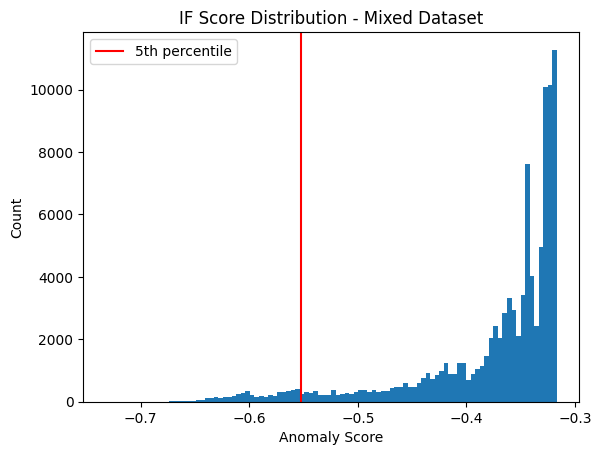

In [15]:
scores = iso_forest.score_samples(X_val)
preds  = iso_forest.predict(X_val)

print(f"Flagged:  {(preds == -1).sum()}")
print(f"Expected: {len(X_val) * 0.05:.0f}")
print(f"\nVal Score Distribution:")
print(f"  Mean: {scores.mean():.4f}")
print(f"  Std:  {scores.std():.4f}")
print(f"  Min:  {scores.min():.4f}")
print(f"  Max:  {scores.max():.4f}")

plt.hist(scores, bins=100)
plt.axvline(x=np.percentile(scores, 5), color='red', label='5th percentile')
plt.title('IF Score Distribution - Mixed Dataset')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.legend()
plt.show()

In [16]:
attack_df = unsw_df[unsw_df['Label'] == 1]

test_sample = attack_df.groupby('attack_cat', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 200), random_state=40)
).reset_index(drop=True)

In [17]:
test_sample['src_is_private'] = test_sample['srcip'].apply(lambda x: ipaddress.ip_address(x).is_private).astype(int)
test_sample['dst_is_private'] = test_sample['dstip'].apply(lambda x: ipaddress.ip_address(x).is_private).astype(int)
test_sample['src_is_loopback'] = test_sample['srcip'].apply(lambda x: ipaddress.ip_address(x).is_loopback).astype(int)
test_sample['dst_is_loopback'] = test_sample['dstip'].apply(lambda x: ipaddress.ip_address(x).is_loopback).astype(int)
test_sample['pkt_ratio']       = test_sample['Spkts'] / (test_sample['Dpkts'] + 1)
test_sample['byte_ratio']      = test_sample['sbytes'] / (test_sample['dbytes'] + 1)

In [18]:
if 'is_sm_ips_ports' not in test_sample.columns:
    test_sample['is_sm_ips_ports'] = 0

In [19]:
test_sample['dsport'] = pd.to_numeric(test_sample['dsport'], errors='coerce').fillna(0).astype(int)

In [20]:
for col, (lower, upper) in clip_bounds.items():
    if col in test_sample.columns:
        test_sample[col] = test_sample[col].clip(lower, upper)

In [21]:
X_attack = test_sample[features].fillna(0)

a_preds  = iso_forest.predict(X_attack)
a_scores = iso_forest.score_samples(X_attack)

In [22]:
detected = (a_preds == -1).sum()
total    = len(X_attack)

print(f"\nAttack Test Results:")
print(f"Total:    {total}")
print(f"Detected: {detected} ({detected/total*100:.1f}%)")
print(f"Missed:   {total-detected} ({(total-detected)/total*100:.1f}%)")


Attack Test Results:
Total:    1974
Detected: 1861 (94.3%)
Missed:   113 (5.7%)


In [23]:
pickle.dump(iso_forest,  open("isolation_forest_mixed.pkl", "wb"))
pickle.dump(clip_bounds, open("clip_bounds_mixed.pkl",      "wb"))
print("\nMixed model saved.")


Mixed model saved.
